In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv',usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [3]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

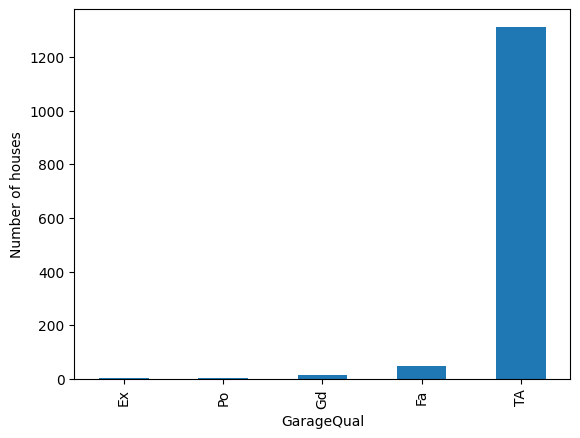

In [5]:
df['GarageQual'].value_counts().sort_values(ascending=True).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [6]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

AttributeError: 'Axes' object has no attribute 'get_legend_handles_lables'

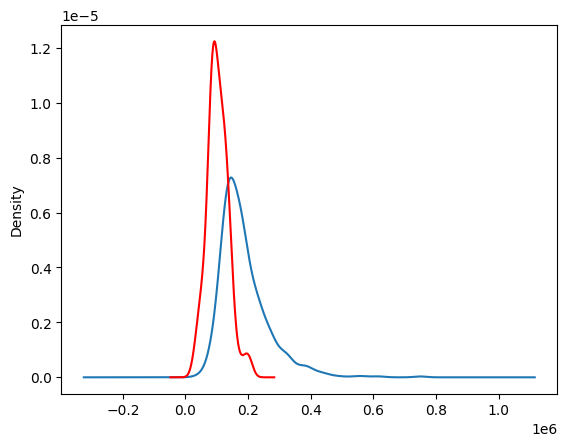

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')
lines,labels = ax.get_legend_handles_lables()
lables = ['House with TA', 'House with NA']
ax.legend(lines,labels,loc='best')
plt.title('GarageQual')

In [14]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [11]:
df['GarageQual'].fillna('TA', inplace=False)

0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: object

<Axes: xlabel='GarageQual'>

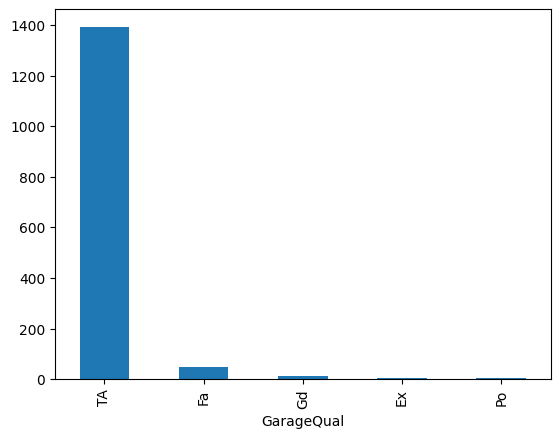

In [12]:
df['GarageQual'].value_counts().plot(kind='bar')


AttributeError: 'Axes' object has no attribute 'get_legend_handles_lables'

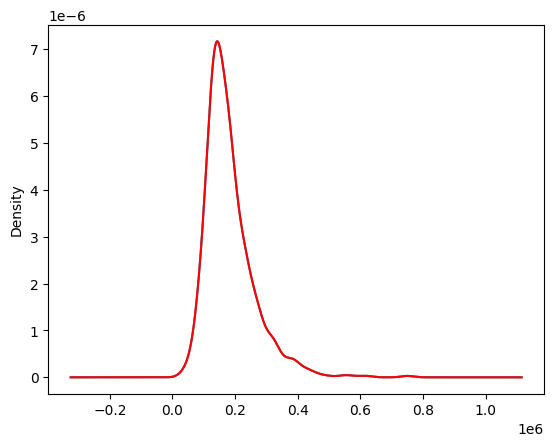

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)
temp.plot(kind='kde', ax=ax)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')
lines,labels = ax.get_legend_handles_lables()
lables = ['Original variable', 'Imputed variable']
ax.legend(lines,labels,loc='best')
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

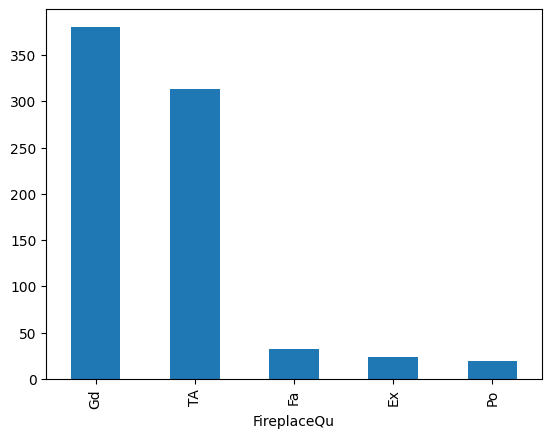

In [16]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [17]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

AttributeError: 'Axes' object has no attribute 'get_legend_handles_lables'

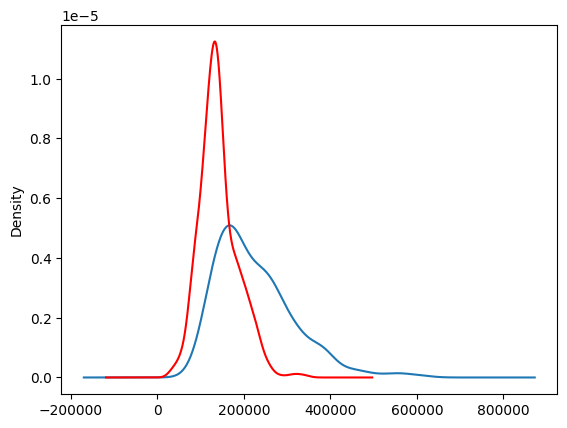

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')
lines,labels = ax.get_legend_handles_lables()
lables = ['House with Gd', 'House with NA']
ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')

In [26]:
df[df['FireplaceQu']=='Gd']['SalePrice']

3       140000
6       307000
11      345000
13      279500
20      325300
         ...  
1437    394617
1440    191000
1443    121000
1451    287090
1457    266500
Name: SalePrice, Length: 380, dtype: int64

<Axes: xlabel='FireplaceQu'>

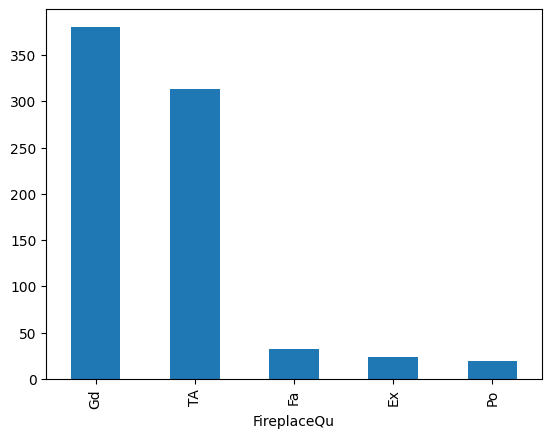

In [27]:
df['FireplaceQu'].value_counts().plot(kind='bar')

AttributeError: 'Axes' object has no attribute 'get_legend_handles_lables'

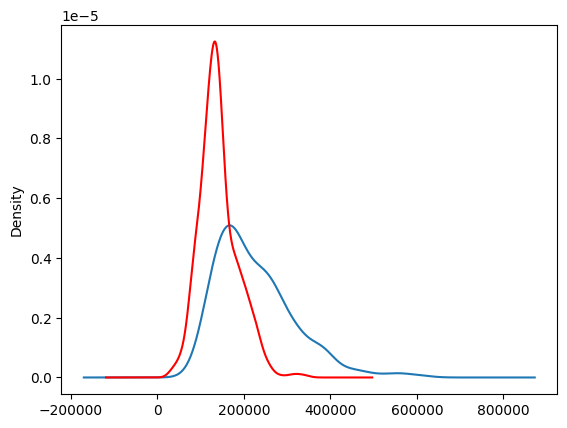

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')
lines,labels = ax.get_legend_handles_lables()
lables = ['House with Gd', 'House with NA']
ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [31]:
from sklearn.impute import SimpleImputer

In [32]:
imputer = SimpleImputer(strategy='most_frequent')

In [34]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_train)

In [35]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)